In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split


In [2]:
# Download MNIST — 70,000 images of handwritten digits (0-9)
print("Downloading MNIST... (takes ~30 seconds)")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data / 255.0        # Pixel values 0-255, normalize to 0-1
y = mnist.target.astype(int)  # Labels: 0,1,2,...,9

# Split: 60,000 for training, 10,000 for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Each image has   : {X_train.shape[1]} pixels (28x28 = 784)")

Training samples : 60000
Test samples     : 10000
Each image has   : 784 pixels (28x28 = 784)


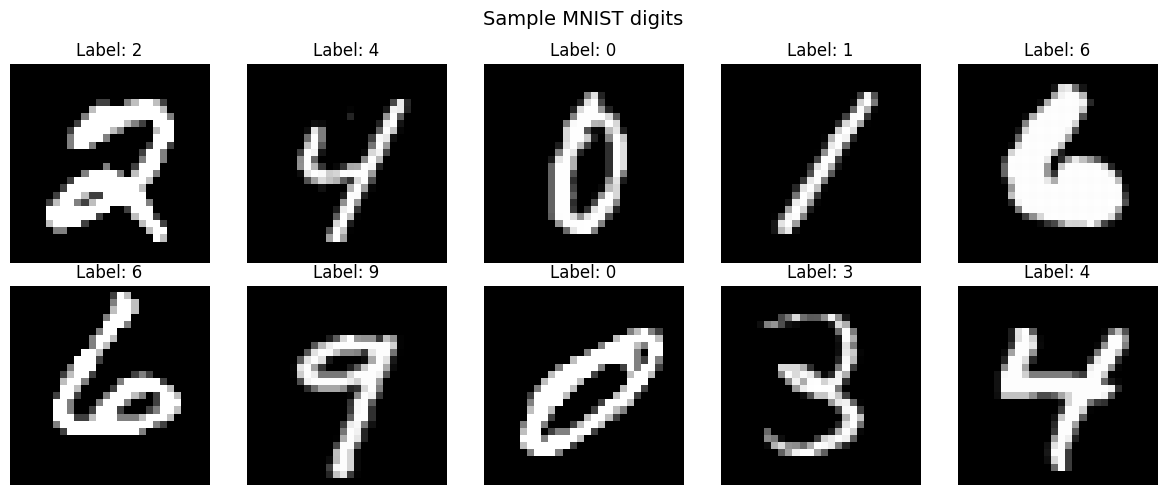

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}", fontsize=12)
    ax.axis('off')
plt.suptitle("Sample MNIST digits", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
class NeuralNetwork:
    """
    A 3-layer neural network built from scratch.
    Architecture: 784 → 128 → 64 → 10
    """

    def __init__(self):
        # --- INITIALIZE WEIGHTS ---
        # Small random numbers so neurons start different from each other
        # Shape (784, 128) means: 784 inputs connect to 128 hidden neurons
        self.W1 = np.random.randn(784, 128) * 0.01
        self.b1 = np.zeros((1, 128))         # Bias for layer 1

        self.W2 = np.random.randn(128, 64) * 0.01
        self.b2 = np.zeros((1, 64))          # Bias for layer 2

        self.W3 = np.random.randn(64, 10) * 0.01
        self.b3 = np.zeros((1, 10))          # Bias for output layer (10 digits)

    # --- ACTIVATION FUNCTIONS ---
    def relu(self, z):
        """ReLU: returns 0 if negative, else returns the value itself"""
        return np.maximum(0, z)

    def relu_derivative(self, z):
        """Derivative of ReLU — used during backpropagation"""
        return (z > 0).astype(float)

    def softmax(self, z):
        """Converts raw scores into probabilities that sum to 1"""
        # Subtract max for numerical stability (prevents overflow)
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    # --- FORWARD PASS ---
    def forward(self, X):
        """
        Pass input data forward through the network.
        Each layer: multiply inputs by weights, add bias, apply activation.
        """
        # Layer 1: input (784) → hidden (128)
        self.z1 = X @ self.W1 + self.b1    # @ = matrix multiply
        self.a1 = self.relu(self.z1)        # Apply ReLU activation

        # Layer 2: hidden (128) → hidden (64)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.relu(self.z2)

        # Layer 3: hidden (64) → output (10 classes)
        self.z3 = self.a2 @ self.W3 + self.b3
        self.a3 = self.softmax(self.z3)     # Probabilities for each digit

        return self.a3

    # --- LOSS FUNCTION ---
    def compute_loss(self, y_pred, y_true):
        """
        Cross-entropy loss: measures how wrong our predictions are.
        Lower is better. 0 = perfect.
        """
        n = y_true.shape[0]
        # One-hot encode: turn label 3 → [0,0,0,1,0,0,0,0,0,0]
        y_one_hot = np.zeros((n, 10))
        y_one_hot[np.arange(n), y_true] = 1

        # Clip to avoid log(0) which is undefined
        y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)

        loss = -np.mean(np.sum(y_one_hot * np.log(y_pred_clipped), axis=1))
        return loss

    # --- BACKPROPAGATION ---
    def backward(self, X, y_true, learning_rate=0.01):
        """
        Backpropagation: figure out how much each weight contributed to the error,
        then nudge all weights to reduce the error.
        """
        n = X.shape[0]

        # One-hot encode labels
        y_one_hot = np.zeros((n, 10))
        y_one_hot[np.arange(n), y_true] = 1

        # --- OUTPUT LAYER GRADIENT ---
        # How wrong were our final predictions?
        dz3 = self.a3 - y_one_hot          # Error at output

        dW3 = self.a2.T @ dz3 / n          # How much did W3 cause this error?
        db3 = np.mean(dz3, axis=0, keepdims=True)

        # --- HIDDEN LAYER 2 GRADIENT ---
        da2 = dz3 @ self.W3.T
        dz2 = da2 * self.relu_derivative(self.z2)  # Apply ReLU derivative

        dW2 = self.a1.T @ dz2 / n
        db2 = np.mean(dz2, axis=0, keepdims=True)

        # --- HIDDEN LAYER 1 GRADIENT ---
        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_derivative(self.z1)

        dW1 = X.T @ dz1 / n
        db1 = np.mean(dz1, axis=0, keepdims=True)

        # --- UPDATE WEIGHTS (Gradient Descent) ---
        # Move weights slightly in the direction that reduces loss
        self.W3 -= learning_rate * dW3
        self.b3 -= learning_rate * db3
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    # --- PREDICTION ---
    def predict(self, X):
        """Run forward pass and return the digit with highest probability"""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)   # Index of max probability = predicted digit

    def accuracy(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)

print("Neural network class defined!")

Neural network class defined!


In [5]:
# Create the neural network
nn = NeuralNetwork()

# Training settings
epochs       = 30          # How many times to loop through ALL training data
batch_size   = 256         # Process 256 images at a time (mini-batch)
learning_rate = 0.1        # How big each weight update step is

loss_history = []
acc_history  = []

print("Training started...\n")

for epoch in range(epochs):
    # --- SHUFFLE data each epoch so order doesn't matter ---
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    # --- MINI-BATCH LOOP ---
    for i in range(0, X_train.shape[0], batch_size):
        # Grab one batch
        X_batch = X_shuffled[i : i + batch_size]
        y_batch = y_shuffled[i : i + batch_size]

        # Forward pass → compute loss → backward pass → update weights
        nn.forward(X_batch)
        nn.backward(X_batch, y_batch, learning_rate)

    # --- EVALUATE after each epoch ---
    loss = nn.compute_loss(nn.forward(X_train[:5000]), y_train[:5000])
    acc  = nn.accuracy(X_test, y_test)

    loss_history.append(loss)
    acc_history.append(acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{epochs}  |  Loss: {loss:.4f}  |  Test Accuracy: {acc*100:.2f}%")

print(f"\n✅ Final Test Accuracy: {nn.accuracy(X_test, y_test)*100:.2f}%")

Training started...

Epoch  5/30  |  Loss: 0.3191  |  Test Accuracy: 89.86%
Epoch 10/30  |  Loss: 0.1576  |  Test Accuracy: 94.48%
Epoch 15/30  |  Loss: 0.1021  |  Test Accuracy: 95.86%
Epoch 20/30  |  Loss: 0.0805  |  Test Accuracy: 96.23%
Epoch 25/30  |  Loss: 0.0566  |  Test Accuracy: 96.68%
Epoch 30/30  |  Loss: 0.0393  |  Test Accuracy: 96.89%

✅ Final Test Accuracy: 96.89%


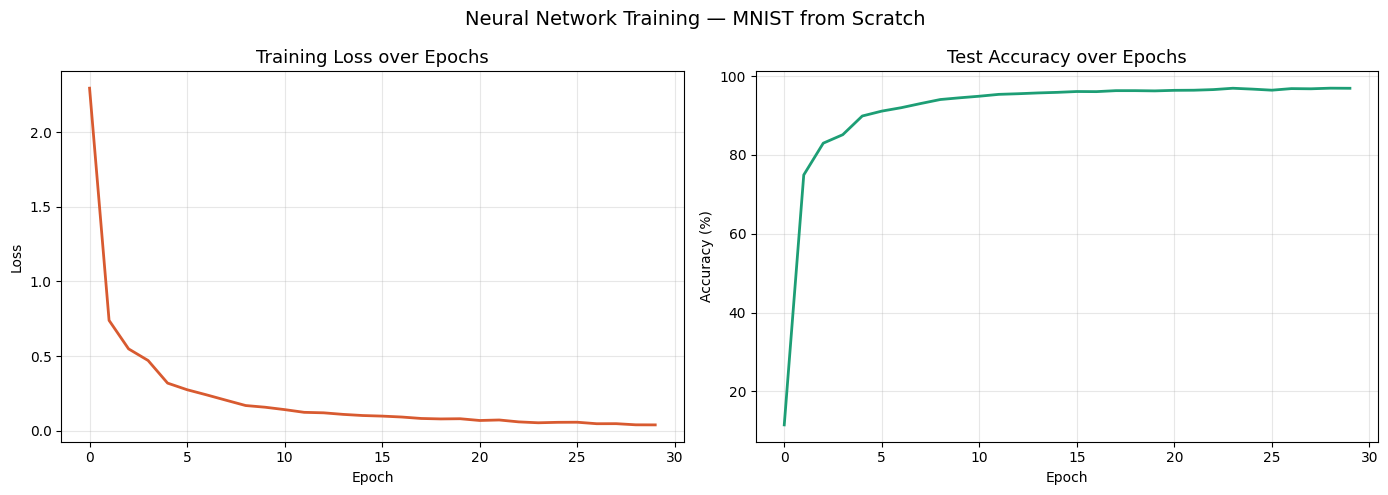

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(loss_history, color='#D85A30', linewidth=2)
ax1.set_title('Training Loss over Epochs', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot([a * 100 for a in acc_history], color='#1D9E75', linewidth=2)
ax2.set_title('Test Accuracy over Epochs', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.suptitle('Neural Network Training — MNIST from Scratch', fontsize=14)
plt.tight_layout()
plt.show()

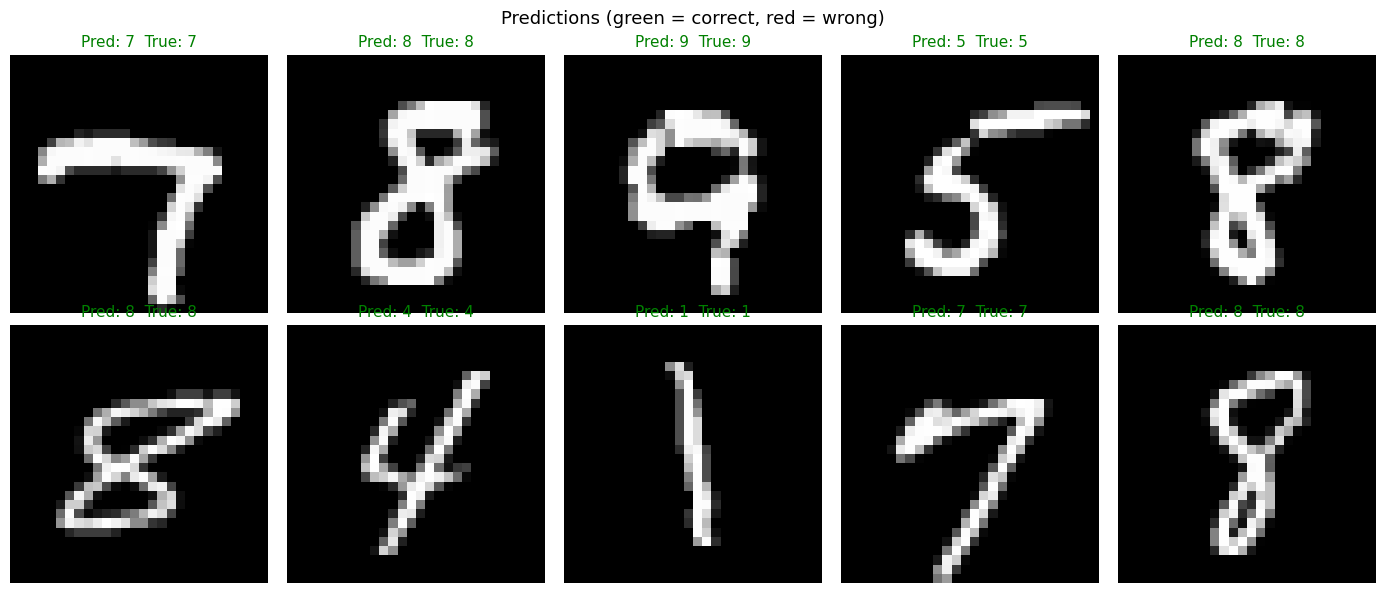

In [7]:
# Show 10 test images with predicted vs true labels
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
test_indices = np.random.choice(len(X_test), 10, replace=False)

for idx, ax in zip(test_indices, axes.flat):
    img = X_test[idx].reshape(28, 28)
    pred = nn.predict(X_test[idx:idx+1])[0]
    true = y_test[idx]
    color = 'green' if pred == true else 'red'
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {pred}  True: {true}", color=color, fontsize=11)
    ax.axis('off')

plt.suptitle('Predictions (green = correct, red = wrong)', fontsize=13)
plt.tight_layout()
plt.show()